Found 19 files.


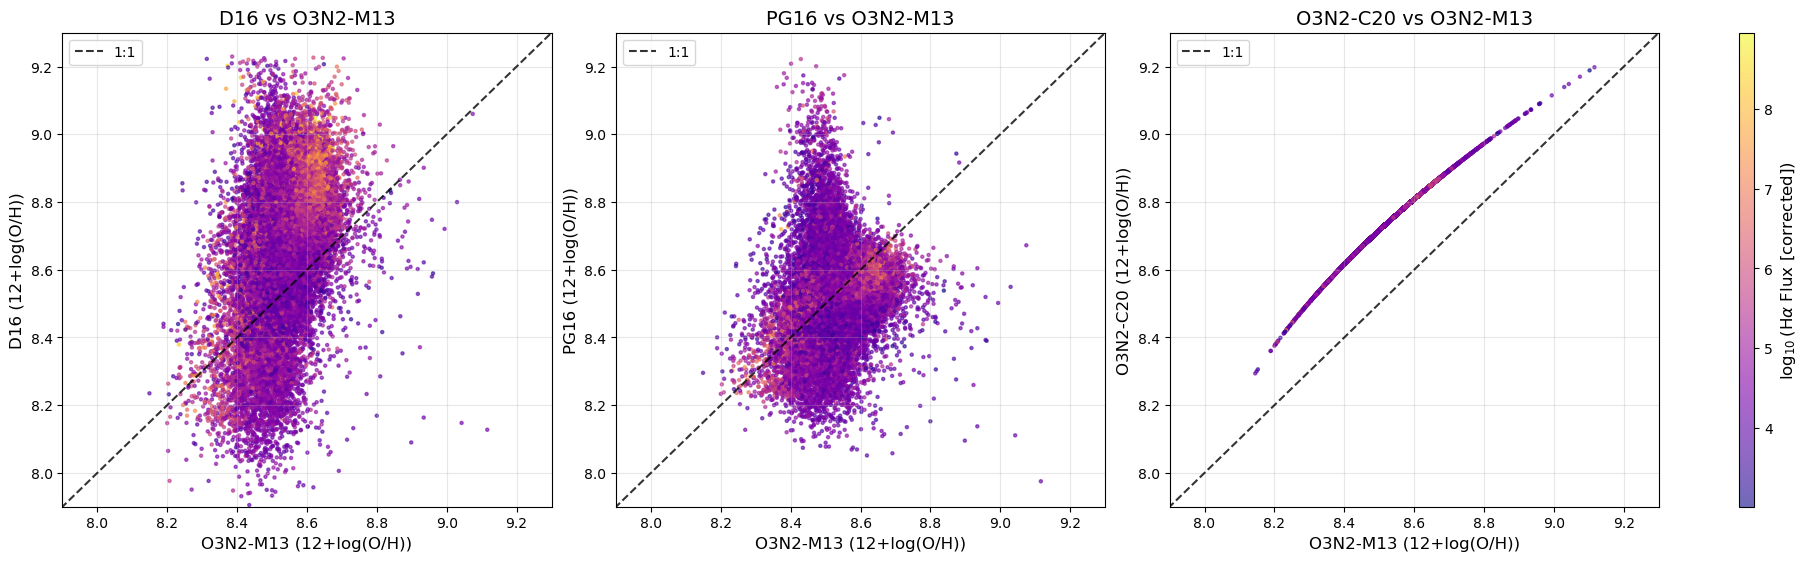

In [4]:
import glob
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

# 1. Collect data
fits_files = glob.glob("*_extended.fits")
print(f"Found {len(fits_files)} files.")

d16_list = []
pg16_list = []
c20_list = []
m13_list = []
ha_list = []

for f in fits_files:
    with fits.open(f) as hdul:
        data = hdul['PHASE3CATALOG'].data
        
        # Read columns
        # Using .copy() to ensure we have numpy arrays
        d16_list.append(data['O_H_D16'].copy())
        pg16_list.append(data['O_H_PG16'].copy())
        c20_list.append(data['O_H_O3N2_C20'].copy())
        m13_list.append(data['O_H_O3N2_M13'].copy())
        ha_list.append(data['HA6562_FLUX_CORR'].copy())

# Concatenate arrays
d16_all = np.concatenate(d16_list)
pg16_all = np.concatenate(pg16_list)
c20_all = np.concatenate(c20_list)
m13_all = np.concatenate(m13_list)
ha_all = np.concatenate(ha_list)

# Filter for valid Halpha flux for log scale
mask = (ha_all > 0)
d16_plot = d16_all[mask]
pg16_plot = pg16_all[mask]
c20_plot = c20_all[mask]
m13_plot = m13_all[mask]
ha_plot = ha_all[mask]

# 2. Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), constrained_layout=True)

# Data for loop
ys = [d16_plot, pg16_plot, c20_plot]
y_labels = ['D16 (12+log(O/H))', 'PG16 (12+log(O/H))', 'O3N2-C20 (12+log(O/H))']
titles = ['D16 vs O3N2-M13', 'PG16 vs O3N2-M13', 'O3N2-C20 vs O3N2-M13']

# Color mapping
c_data = np.log10(ha_plot)

# Common limits for metallicity
lims = [7.9, 9.3] 

for i, ax in enumerate(axes):
    y_data = ys[i]
    x_data = m13_plot
    
    # Scatter plot
    sc = ax.scatter(x_data, y_data, c=c_data, cmap='plasma', s=5, alpha=0.6)
    
    # One-to-one line
    ax.plot([7, 10], [7, 10], 'k--', alpha=0.8, label='1:1')
    
    ax.set_xlabel('O3N2-M13 (12+log(O/H))', fontsize=12)
    ax.set_ylabel(y_labels[i], fontsize=12)
    ax.set_title(titles[i], fontsize=14)
    
    # Set limits to focus on data range
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper left')

# Colorbar
cbar = fig.colorbar(sc, ax=axes, location='right', aspect=30)
cbar.set_label(r'$\log_{10}(\mathrm{H}\alpha\ \mathrm{Flux\ [corrected]})$', fontsize=12)

plt.show()

Checking equality element by element...
Mismatch at index 0: MET_SCAL=8.51298495650336, PG16=8.514399050902805, Diff=-0.001414094399445176
Mismatch at index 1: MET_SCAL=8.657874137597933, PG16=8.659337345236665, Diff=-0.0014632076387322002
Mismatch at index 2: MET_SCAL=8.589341917702438, PG16=8.5908243252606, Diff=-0.0014824075581625351
Mismatch at index 3: MET_SCAL=8.61017285702692, PG16=8.611506988692977, Diff=-0.0013341316660575586
Mismatch at index 4: MET_SCAL=nan, PG16=8.669548604717463, Diff=nan
Mismatch at index 5: MET_SCAL=nan, PG16=8.586557614741418, Diff=nan
Mismatch at index 6: MET_SCAL=nan, PG16=8.692927729486339, Diff=nan
Mismatch at index 7: MET_SCAL=8.568066093444584, PG16=8.569478770551157, Diff=-0.0014126771065736676
Mismatch at index 8: MET_SCAL=8.638061326395164, PG16=8.639460828956848, Diff=-0.001399502561683974
Mismatch at index 9: MET_SCAL=8.597119770510332, PG16=8.598701340375001, Diff=-0.0015815698646690635
Found 31384 mismatches out of 31384 points.


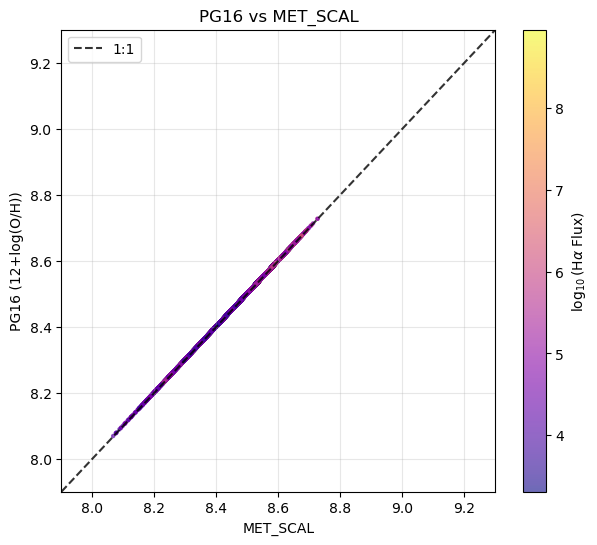

In [6]:
# Check MET_SCAL vs PG16
met_scal_list = []
pg16_check_list = []
ha_check_list = []

# Ensure fits_files is defined
if 'fits_files' not in locals():
    fits_files = glob.glob("*_extended.fits")

for f in fits_files:
    with fits.open(f) as hdul:
        data = hdul['PHASE3CATALOG'].data
        # Check if MET_SCAL exists to avoid KeyError if user made a typo, 
        # but assuming user knows it exists.
        if 'MET_SCAL' in data.columns.names:
            met_scal_list.append(data['MET_SCAL'].copy())
        else:
            met_scal_list.append(data['MET_SCAL'].copy())
            
        pg16_check_list.append(data['O_H_PG16'].copy())
        ha_check_list.append(data['HA6562_FLUX_CORR'].copy())

met_scal_all = np.concatenate(met_scal_list)
pg16_check_all = np.concatenate(pg16_check_list)
ha_check_all = np.concatenate(ha_check_list)

# Filter
mask = (ha_check_all > 0)
met_scal_plot = met_scal_all[mask]
pg16_check_plot = pg16_check_all[mask]

# Check equality loop
print("Checking equality element by element...")
mismatches = 0
for i in range(len(met_scal_plot)):
    v1 = met_scal_plot[i]
    v2 = pg16_check_plot[i]
    
    if v1 != v2:
        mismatches += 1
        if mismatches <= 10:
            print(f"Mismatch at index {i}: MET_SCAL={v1}, PG16={v2}, Diff={v1-v2}")

if mismatches == 0:
    print("All values are exactly equal!")
else:
    print(f"Found {mismatches} mismatches out of {len(met_scal_plot)} points.")

# Plot
fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(met_scal_plot, pg16_check_plot, c=np.log10(ha_check_all[mask]), cmap='plasma', s=5, alpha=0.6)

# 1:1 line
lims = [7.9, 9.3] # Using same limits as previous plot for consistency
ax.plot(lims, lims, 'k--', alpha=0.8, label='1:1')

ax.set_xlabel('MET_SCAL')
ax.set_ylabel('PG16 (12+log(O/H))')
ax.set_title('PG16 vs MET_SCAL')
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.grid(True, alpha=0.3)
ax.legend()

# Colorbar
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label(r'$\log_{10}(\mathrm{H}\alpha\ \mathrm{Flux})$')

plt.show()